In [1]:
import scanpy as sc
import harmonypy as hm

In [3]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/Data/SmoNull_Brain_system.h5ad")


In [4]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype', 'leiden_0_25_log1p', 'leiden_0_25_scran', 'leiden_0_25_pearson', 'leiden_0_5_log1p', 'leiden_0_5_scran', 'leiden_0_5_pearson', 'leiden_1_log1p', 'leiden_1_scran', 'leiden_1_pearson', 'leiden_2_log1p', 'leiden_2_scran', 'leiden_2_pearson', 'leiden_3_log1p', 'leiden_3_scran', 'leiden_3_pearson', 'leiden_5_log1p', 'leiden_5_scran', 'leiden_5_pearson'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_va

# Integration with Pearson Residual Normalization

## Finding Highly Variable Genes 

In [5]:
# Expects raw data
adata.X = adata.layers["raw_counts"]

In [ ]:
# Using experimental that allow for pearson_residual flavors
# Default flavor is pearson residual
sc.experimental.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Library.ident")

In [8]:
# Renaming to pearson
adata.var["highly_variable_pearson"] = adata.var["highly_variable"]
del adata.var["highly_variable"]
adata.var["highly_variable_nbatches_pearson"] = adata.var["highly_variable_nbatches"]
del adata.var["highly_variable_nbatches"]
adata.var["highly_variable_intersection_pearson"] = adata.var["highly_variable_intersection"]
del adata.var["highly_variable_intersection"]
adata.var["highly_variable_rank(pearson)"] = adata.var["highly_variable_rank"]
del adata.var["highly_variable_rank"]
adata.uns["hvg_pearson"] = adata.uns["hvg"]
del adata.uns["hvg"]

### Finding PCA


In [5]:
# Remember to switch to pearson
adata.X = adata.layers["analytic_pearson_residuals"]

In [6]:
# No need to scale, unlike log1p because pearson already 0 centered
# Make sure to use only highly_var_genes marked by pearson
sc.pp.pca(adata, mask_var="highly_variable_pearson")

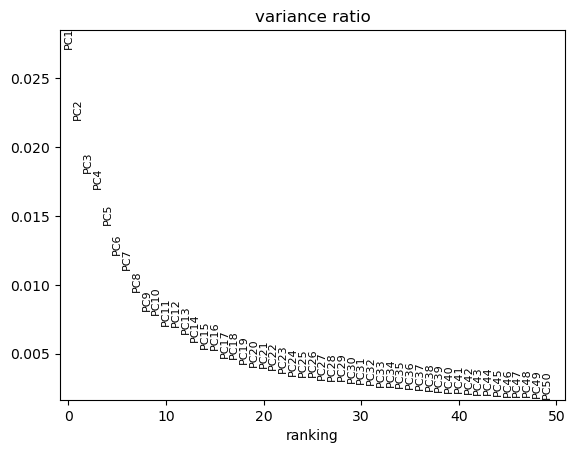

In [7]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False)

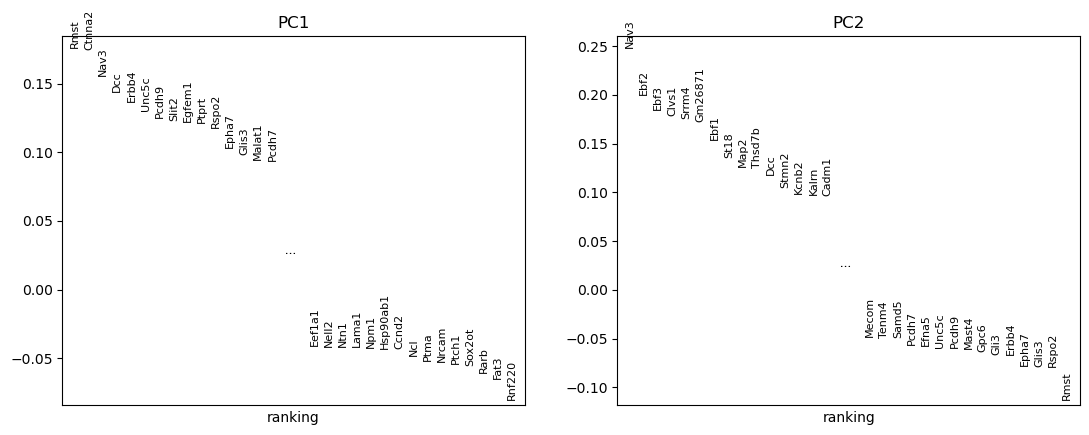

In [8]:
sc.pl.pca_loadings(adata, components = [1,2], show = True)

In [9]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype', 'leiden_0_25_log1p', 'leiden_0_25_scran', 'leiden_0_25_pearson', 'leiden_0_5_log1p', 'leiden_0_5_scran', 'leiden_0_5_pearson', 'leiden_1_log1p', 'leiden_1_scran', 'leiden_1_pearson', 'leiden_2_log1p', 'leiden_2_scran', 'leiden_2_pearson', 'leiden_3_log1p', 'leiden_3_scran', 'leiden_3_pearson', 'leiden_5_log1p', 'leiden_5_scran', 'leiden_5_pearson'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_va

In [10]:
# Again taking only a subset of pc for downstream processing
adata.obsm["X_pca_pearson"] = adata.obsm["X_pca"][:, :13]
del adata.obsm["X_pca"]

### Harmony Integration

In [11]:
sc.external.pp.harmony_integrate(adata, key="Library.ident", max_iter_harmony=20, basis = "X_pca_pearson", adjusted_basis="X_pca_harmony_pearson")

2026-03-21 13:59:24,335 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-03-21 13:59:27,204 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-03-21 13:59:27,330 - harmonypy - INFO - Iteration 1 of 20
2026-03-21 13:59:34,265 - harmonypy - INFO - Iteration 2 of 20
2026-03-21 13:59:41,210 - harmonypy - INFO - Iteration 3 of 20
2026-03-21 13:59:48,155 - harmonypy - INFO - Iteration 4 of 20
2026-03-21 13:59:55,104 - harmonypy - INFO - Iteration 5 of 20
2026-03-21 14:00:02,060 - harmonypy - INFO - Iteration 6 of 20
2026-03-21 14:00:09,018 - harmonypy - INFO - Iteration 7 of 20
2026-03-21 14:00:10,915 - harmonypy - INFO - Iteration 8 of 20
2026-03-21 14:00:12,810 - harmonypy - INFO - Converged after 8 iterations


In [17]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_variable_pearson', 'highly_variable_nbatches_pearson', 'highly_variable_intersection_pearson', 'highly_variable_rank(pearson)'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'hvg_log1p', 'neighbors_log1p', 'pca', 'hvg_pearson'
    obsm: 'X_pca_harmony_log1p', 'X_pca_log1p', 'X_umap_log1p', 'X_pca_pearson', 

### Calculating Neightbor + Umap

In [12]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony_pearson", key_added="neighbors_pearson")

/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
sc.tl.umap(adata, neighbors_key="neighbors_pearson", key_added="X_umap_pearson")

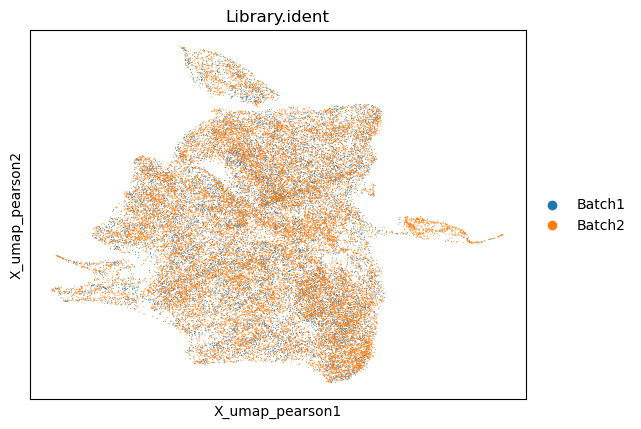

In [14]:
sc.pl.embedding(adata, basis = "X_umap_pearson", color = "Library.ident", size = 2)

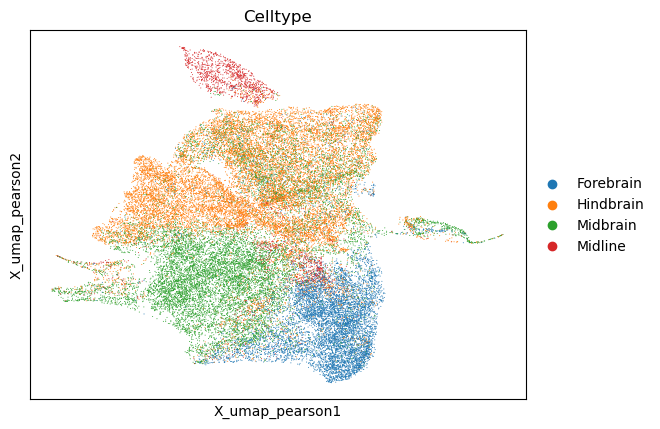

In [23]:
sc.pl.embedding(adata, basis = "X_umap_pearson", color = "Celltype", size = 2)

In [24]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'residual_variances', 'highly_variable_pearson', 'highly_variable_nbatches_pearson', 'highly_variable_intersection_pearson', 'highly_variable_rank(pearson)'
    uns: 'Celltype_colors', 'ClusterSystem_colors', 'Library.ident_colors', 'X_umap_log1p', 'hvg_log1p', 'neighbors_log1p', 'pca', 'hvg_pearson', 'neighbors_pearson', 'X_umap_pearson'
    obsm: 'X_pca_harmony_log1p', 'X_pca_lo

In [ ]:
#adata.write_h5ad("/project/imoskowitz/yubin/1-sc_practice/SmoNull_Brain_system.h5ad")